# Praktikum Asistensi Mata Kuliah Data Wrangling

## Topik: Data Cleaning dan Imputasi Data Missing Values

## 1. Pendahuluan

Data Wrangling adalah proses membersihkan, mentransformasi, dan mempersiapkan data untuk analisis lebih lanjut. Proses ini sangat penting karena data di dunia nyata seringkali tidak lengkap, tidak konsisten, atau mengandung nilai-nilai yang tidak valid.

### Langkah-langkah Utama Data Wrangling:
1. **Data Collection** - Mengumpulkan data dari berbagai sumber
2. **Data Cleaning** - Membersihkan data dari nilai-nilai yang tidak valid
3. **Data Transformation** - Mengubah format data sesuai kebutuhan
4. **Data Imputation** - Mengisi nilai yang hilang (missing values)
5. **Data Validation** - Memastikan data sudah valid dan siap digunakan

## 2. Memahami Missing Values

Missing values (nilai yang hilang) adalah masalah umum dalam analisis data. Sebelum melakukan imputasi, kita perlu memahami jenis-jenis missing values:

### 2.1 MCAR (Missing Completely At Random)

**Definisi:** Data missing tidak bergantung pada nilai variabel lain maupun nilai itu sendiri.

**Contoh:** 
- Responden lupa menjawab beberapa pertanyaan secara acak
- Scanner barcode gagal membaca beberapa produk secara acak
- Data entry error yang terjadi secara random

**Ciri-ciri:**
- Probabilitas missing sama untuk semua observasi
- Tidak ada pola tertentu dalam missing data
- Missing values tidak berhubungan dengan variabel lain

### 2.2 MAR (Missing At Random)

**Definisi:** Data missing bergantung pada variabel lain yang diamati, tetapi tidak pada nilai itu sendiri.

**Contoh:**
- Pria lebih cenderung tidak menjawab pertanyaan tentang emosi dibandingkan wanita
- Responden dengan pendidikan tinggi lebih mungkin tidak menjawab pertanyaan tentang pendapatan
- Pasien dengan gejala ringan lebih mungkin tidak datang untuk follow-up

**Ciri-ciri:**
- Missing patterns dapat dijelaskan oleh variabel lain
- Masih dapat di-handle dengan imputasi yang tepat
- Perlu mempertimbangkan variabel lain dalam imputasi

### 2.3 MNAR (Missing Not At Random)

**Definisi:** Data missing bergantung pada nilai itu sendiri (nilai yang tidak diketahui).

**Contoh:**
- Orang dengan pendapatan sangat tinggi cenderung tidak melaporkan pendapatannya
- Pasien dengan gejala parah cenderung tidak mengisi kuesioner kesehatan
- Siswa dengan nilai jelek cenderung tidak melaporkan nilainya

**Ciri-ciri:**
- Missing terjadi karena nilai itu sendiri
- Sulit untuk di-handle dengan imputasi standar
- Memerlukan metode advanced atau domain knowledge

## 3. Persiapan Lingkungan dan Data

In [39]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import warnings
warnings.filterwarnings('ignore')

# Set style untuk visualisasi
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [40]:
### Membaca Dataset dari File CSV
df_mahasiswa = pd.read_csv('dataset_mahasiswa.csv')
print("Dataset Mahasiswa (5 baris pertama):")
print(df_mahasiswa.head())
print(f"\nUkuran dataset: {df_mahasiswa.shape}")

Dataset Mahasiswa (5 baris pertama):
   NIM         Nama  Umur   IPK  Jumlah_Saudara      Asal Status
0    1  Mahasiswa_1  21.0  3.45               2   Jakarta  Aktif
1    2  Mahasiswa_2  19.0  2.89               1  Surabaya  Aktif
2    3  Mahasiswa_3  22.0  3.78               0   Bandung  Aktif
3    4  Mahasiswa_4  20.0  3.12               3     Medan  Aktif
4    5  Mahasiswa_5  23.0  3.91               1  Semarang  Aktif

Ukuran dataset: (100, 7)


In [4]:
# Dataset 2: Data Penjualan (untuk latihan imputasi)

df_penjualan = pd.read_csv('dataset_penjualan.csv')
print("Dataset Penjualan (5 baris pertama):")
print(df_penjualan.head())
print(f"\nUkuran dataset: {df_penjualan.shape}")
print("\nInformasi kolom:")
print(df_penjualan.dtypes)

Dataset Penjualan (5 baris pertama):
   ID_Transaksi              Tanggal    Produk  Harga  Jumlah   Total  \
0             1  2024-01-01 00:00:00    Laptop   5000       2  9500.0   
1             2  2024-01-01 01:00:00     Mouse    150       5   675.0   
2             3  2024-01-01 02:00:00  Keyboard    200       3   540.0   
3             4  2024-01-01 03:00:00   Monitor   2000       1  1700.0   
4             5  2024-01-01 04:00:00   Printer    800       2  1360.0   

   Rating_Customer  Diskon  
0                4    0.05  
1                3    0.10  
2                5    0.10  
3                4    0.15  
4                2    0.15  

Ukuran dataset: (100, 8)

Informasi kolom:
ID_Transaksi         int64
Tanggal             object
Produk              object
Harga                int64
Jumlah               int64
Total              float64
Rating_Customer      int64
Diskon             float64
dtype: object


## 4. Bagian 1: Dasar-Dasar Data Wrangling

### 4.1 Eksplorasi Data Dasar

#### 4.1.1 Pengenalan Visualisasi untuk EDA (Exploratory Data Analysis)

**Apa itu EDA?**
Exploratory Data Analysis (EDA) adalah proses investigasi awal pada data untuk:
- Mengidentifikasi pola, anomali, dan hubungan dalam data
- Memahami karakteristik distribusi variabel
- Mendeteksi outliers dan missing values
- Membentuk hipotesis untuk analisis lebih lanjut

**Jenis-jenis Visualisasi EDA:**

1. **Univariate Analysis** - Analisis satu variabel:
   - Histogram: Melihat distribusi frekuensi
   - Box Plot: Identifikasi outliers dan kuartil
   - Density Plot: Distribusi probabilitas
   - Bar Chart: Frekuensi kategori

2. **Bivariate Analysis** - Analisis hubungan dua variabel:
   - Scatter Plot: Hubungan antara dua numerik
   - Correlation Heatmap: Korelasi antar variabel
   - Box Plot berkelompok: Perbandingan kategori vs numerik
   - Violin Plot: Distribusi per kategori

3. **Multivariate Analysis** - Analisis lebih dari dua variabel:
   - Pair Plot: Hubungan semua pasangan variabel
   - 3D Scatter Plot: Visualisasi tiga dimensi
   - Clustered Heatmap: Pengelompokan berdasarkan korelasi

**Pentingnya Visualisasi dalam EDA:**
- ✅ Mempercepat pemahaman karakteristik data
- ✅ Mendeteksi pola yang tidak terlihat dalam angka
- ✅ Mengidentifikasi outliers dan anomali
- ✅ Memvalidasi asumsi statistik
- ✅ Komunikasi hasil analisis secara efektif

In [41]:
# Melihat informasi dasar dataset
print("Informasi Dataset Mahasiswa:")
print(df_mahasiswa.info())

print("\nStatistik Deskriptif:")
print(df_mahasiswa.describe())

Informasi Dataset Mahasiswa:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   NIM             100 non-null    int64  
 1   Nama            100 non-null    object 
 2   Umur            97 non-null     float64
 3   IPK             98 non-null     float64
 4   Jumlah_Saudara  100 non-null    int64  
 5   Asal            98 non-null     object 
 6   Status          100 non-null    object 
dtypes: float64(2), int64(2), object(3)
memory usage: 5.6+ KB
None

Statistik Deskriptif:
              NIM       Umur        IPK  Jumlah_Saudara
count  100.000000  97.000000  98.000000      100.000000
mean    50.500000  20.649485   3.297449        1.640000
std     29.011492   1.848655   0.429414        1.337267
min      1.000000  18.000000   2.640000        0.000000
25%     25.750000  19.000000   2.902500        0.750000
50%     50.500000  21.000000   3.3800

In [6]:
# tipe tiap kolom
print(df_mahasiswa.dtypes)

NIM                 int64
Nama               object
Umur              float64
IPK               float64
Jumlah_Saudara      int64
Asal               object
Status             object
dtype: object


In [7]:
# ringkasan duplikat
total = df_mahasiswa.duplicated().sum()
print(f"Total duplikat (baris): {total}")


Total duplikat (baris): 0


In [8]:
# cek duplikat NIM dan Nama jika ada
for k in ['NIM','Nama']:
    if k in df_mahasiswa.columns:
        print(k, "->", df_mahasiswa[k].duplicated().sum())


NIM -> 0
Nama -> 0


In [9]:
# tampilkan baris yang duplikat (keep=False)
dups = df_mahasiswa[df_mahasiswa.duplicated(keep=False)]
if not dups.empty:
    display(dups.reset_index(drop=True))
else:
    print("Tidak ada baris duplikat")


Tidak ada baris duplikat


In [10]:
# fungsi singkat: kembalikan df baru dan jumlah yang dihapus
def remove_duplicates(df, subset=None, keep='first'):
    before = len(df)
    out = df.drop_duplicates(subset=subset, keep=keep)
    return out, before - len(out)

# contoh (commented):
# df_clean, removed = remove_duplicates(df_mahasiswa, subset=['NIM'])
# print("Dihapus:", removed)

### 4.2 Mengenali dan Mengatasi Missing Values

In [11]:
# Memeriksa missing values
print("\nMissing Values per Kolom:")
print(df_mahasiswa.isnull().sum())


Missing Values per Kolom:
NIM               0
Nama              0
Umur              3
IPK               2
Jumlah_Saudara    0
Asal              2
Status            0
dtype: int64


In [ ]:
# Ganti nilai aneh seperti "?" menjadi NaN Jika ada
df_mahasiswa = df_mahasiswa.replace(['?', 'N/A', '/'], pd.NA)

In [13]:
# Memeriksa missing values
print("Jumlah Missing Values per Kolom:")
print(df_mahasiswa.isnull().sum())

print("\nPersentase Missing Values per Kolom:")
print((df_mahasiswa.isnull().sum() / len(df_mahasiswa) * 100).round(2))

Jumlah Missing Values per Kolom:
NIM               0
Nama              0
Umur              3
IPK               2
Jumlah_Saudara    0
Asal              2
Status            0
dtype: int64

Persentase Missing Values per Kolom:
NIM               0.0
Nama              0.0
Umur              3.0
IPK               2.0
Jumlah_Saudara    0.0
Asal              2.0
Status            0.0
dtype: float64


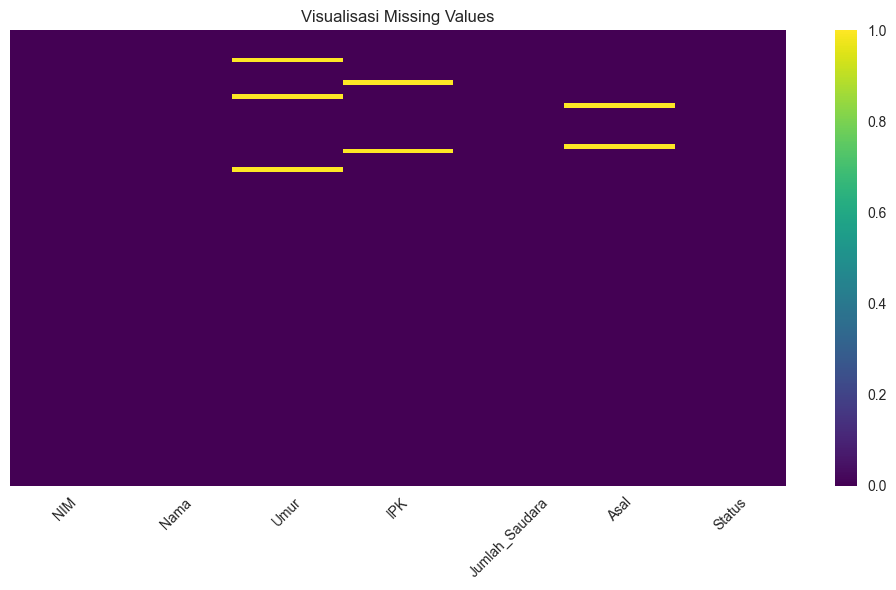

In [14]:
# Visualisasi missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df_mahasiswa.isnull(), yticklabels=False, cbar=True, cmap='viridis')
plt.title('Visualisasi Missing Values')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

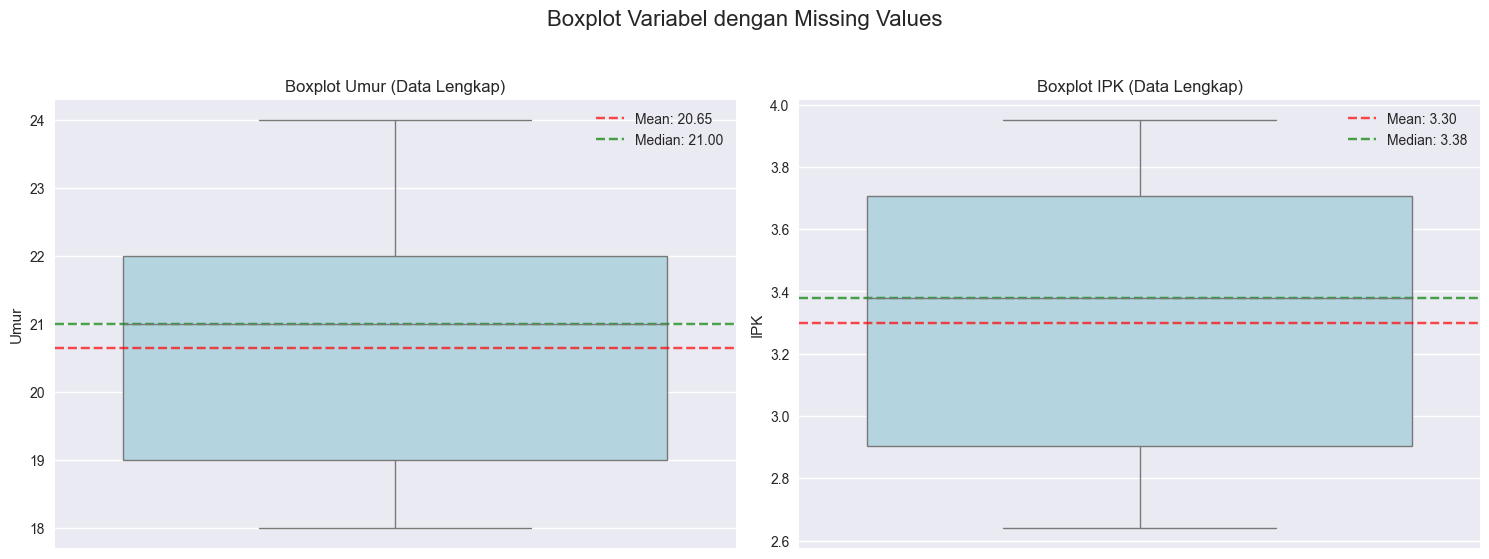

In [15]:
# Visualisasi tambahan: Boxplot untuk melihat distribusi data dengan missing values
plt.figure(figsize=(15, 10))

# Boxplot untuk kolom numerik yang memiliki missing values
numeric_cols_with_missing = ['Umur', 'IPK']

for i, col in enumerate(numeric_cols_with_missing, 1):
    plt.subplot(2, 2, i)
    
    # Boxplot data asli (tanpa missing values)
    sns.boxplot(y=df_mahasiswa[col].dropna(), color='lightblue')
    plt.title(f'Boxplot {col} (Data Lengkap)')
    plt.ylabel(col)
    
    # Tambahkan statistik
    mean_val = df_mahasiswa[col].mean()
    median_val = df_mahasiswa[col].median()
    plt.axhline(y=mean_val, color='red', linestyle='--', alpha=0.7, label=f'Mean: {mean_val:.2f}')
    plt.axhline(y=median_val, color='green', linestyle='--', alpha=0.7, label=f'Median: {median_val:.2f}')
    plt.legend()

plt.suptitle('Boxplot Variabel dengan Missing Values', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

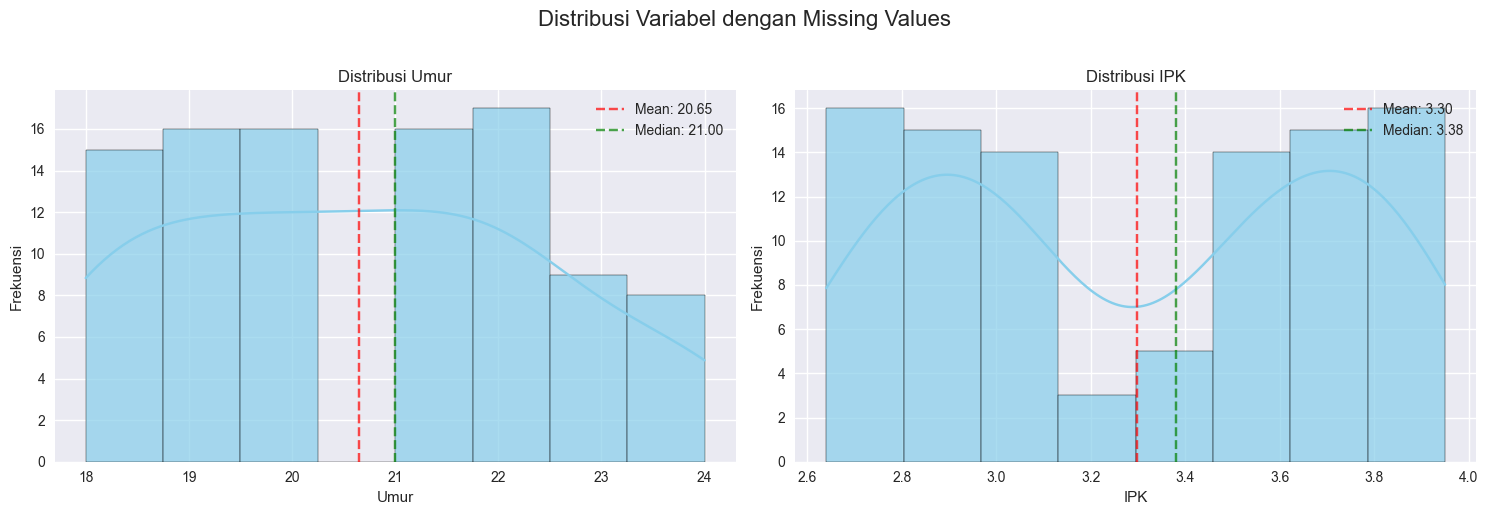

In [16]:
# Visualisasi distribusi untuk variabel dengan missing values
plt.figure(figsize=(15, 5))

for i, col in enumerate(numeric_cols_with_missing, 1):
    plt.subplot(1, 2, i)
    
    # Histogram data asli
    sns.histplot(df_mahasiswa[col].dropna(), kde=True, color='skyblue', alpha=0.7)
    plt.title(f'Distribusi {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    
    # Tambahkan garis statistik
    mean_val = df_mahasiswa[col].mean()
    median_val = df_mahasiswa[col].median()
    plt.axvline(x=mean_val, color='red', linestyle='--', alpha=0.7, label=f'Mean: {mean_val:.2f}')
    plt.axvline(x=median_val, color='green', linestyle='--', alpha=0.7, label=f'Median: {median_val:.2f}')
    plt.legend()

plt.suptitle('Distribusi Variabel dengan Missing Values', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, 'NIM'),
  Text(1, 0, 'Nama'),
  Text(2, 0, 'Umur'),
  Text(3, 0, 'IPK'),
  Text(4, 0, 'Jumlah_Saudara'),
  Text(5, 0, 'Asal'),
  Text(6, 0, 'Status')])

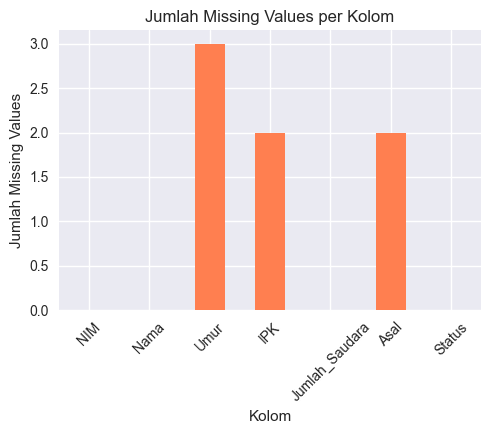

In [17]:
# Visualisasi missing values patterns
plt.figure(figsize=(12, 8))

# Missing values pattern menggunakan matrix
missing_data = df_mahasiswa.isnull()
missing_counts = missing_data.sum()

plt.subplot(2, 2, 1)
missing_counts.plot(kind='bar', color='coral')
plt.title('Jumlah Missing Values per Kolom')
plt.xlabel('Kolom')
plt.ylabel('Jumlah Missing Values')
plt.xticks(rotation=45)

(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, 'NIM'),
  Text(1, 0, 'Nama'),
  Text(2, 0, 'Umur'),
  Text(3, 0, 'IPK'),
  Text(4, 0, 'Jumlah_Saudara'),
  Text(5, 0, 'Asal'),
  Text(6, 0, 'Status')])

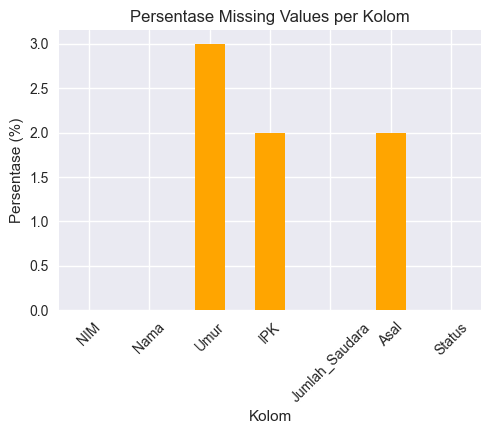

In [18]:
plt.figure(figsize=(12, 8))

# Persentase missing values
plt.subplot(2, 2, 2)
missing_percentages = (missing_counts / len(df_mahasiswa)) * 100
missing_percentages.plot(kind='bar', color='orange')
plt.title('Persentase Missing Values per Kolom')
plt.xlabel('Kolom')
plt.ylabel('Persentase (%)')
plt.xticks(rotation=45)

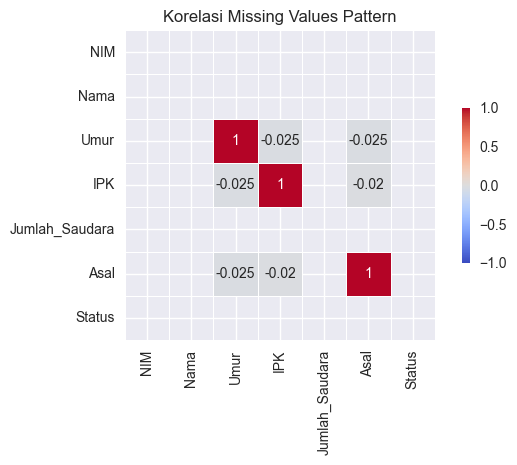

In [19]:
plt.figure(figsize=(12, 8))

# Missing pattern heatmap
plt.subplot(2, 2, 3)
sns.heatmap(missing_data.corr(), annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, vmin=-1, vmax=1, cbar_kws={'shrink': 0.5})
plt.title('Korelasi Missing Values Pattern')

# Tambahkan penyesuaian layout
plt.tight_layout()

# Tampilkan plot
plt.show()

Text(0.5, 1.0, 'Proporsi Missing Values')

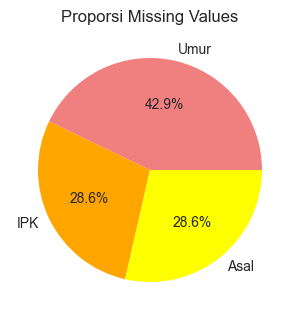

In [20]:
plt.figure(figsize=(12, 8))

# Proporsi missing values
plt.subplot(2, 2, 4)
plt.pie(missing_counts[missing_counts > 0], 
        labels=missing_counts[missing_counts > 0].index,
        autopct='%1.1f%%',
        colors=['lightcoral', 'orange', 'yellow'])
plt.title('Proporsi Missing Values')

### 4.3 Teknik Dasar Imputasi Missing Values

#### 4.3.1 Imputasi dengan Mean (untuk data numerik)

In [21]:
# Imputasi Umur dengan mean
df_mean_imputed = df_mahasiswa.copy()

mean_umur = df_mean_imputed['Umur'].mean()
print(f"Rata-rata umur: {mean_umur:.2f}")

# Imputasi missing values dengan mean
df_mean_imputed['Umur'].fillna(mean_umur, inplace=True)

print("\nSetelah imputasi umur dengan mean:")
print(f"Jumlah missing values umur: {df_mean_imputed['Umur'].isnull().sum()}")
print(f"Rata-rata umur setelah imputasi: {df_mean_imputed['Umur'].mean():.2f}")

Rata-rata umur: 20.65

Setelah imputasi umur dengan mean:
Jumlah missing values umur: 0
Rata-rata umur setelah imputasi: 20.65


#### 4.3.2 Imputasi dengan Median (untuk data numerik)

In [22]:
# Imputasi IPK dengan median
median_ipk = df_mean_imputed['IPK'].median()
print(f"Median IPK: {median_ipk:.2f}")

# Imputasi missing values dengan median
df_mean_imputed['IPK'].fillna(median_ipk, inplace=True)

print("\nSetelah imputasi IPK dengan median:")
print(f"Jumlah missing values IPK: {df_mean_imputed['IPK'].isnull().sum()}")
print(f"Median IPK setelah imputasi: {df_mean_imputed['IPK'].median():.2f}")

Median IPK: 3.38

Setelah imputasi IPK dengan median:
Jumlah missing values IPK: 0
Median IPK setelah imputasi: 3.38


#### 4.3.3 Imputasi dengan Modus (untuk data kategorikal)

In [23]:
# Imputasi Asal dengan modus
modus_asal = df_mean_imputed['Asal'].mode()[0]
print(f"Modus Asal: {modus_asal}")

# Imputasi missing values dengan modus
df_mean_imputed['Asal'].fillna(modus_asal, inplace=True)

print("\nSetelah imputasi Asal dengan modus:")
print(f"Jumlah missing values Asal: {df_mean_imputed['Asal'].isnull().sum()}")
print(f"Distribusi Asal setelah imputasi:")
print(df_mean_imputed['Asal'].value_counts())

Modus Asal: Bandung

Setelah imputasi Asal dengan modus:
Jumlah missing values Asal: 0
Distribusi Asal setelah imputasi:
Asal
Bandung     22
Medan       20
Semarang    20
Jakarta     19
Surabaya    19
Name: count, dtype: int64


In [24]:
# Cek apakah masih ada missing values
print("Jumlah Missing Values Setelah Imputasi Dasar:")
print(df_mean_imputed.isnull().sum())
print(f"\nTotal missing values: {df_mean_imputed.isnull().sum().sum()}")

Jumlah Missing Values Setelah Imputasi Dasar:
NIM               0
Nama              0
Umur              0
IPK               0
Jumlah_Saudara    0
Asal              0
Status            0
dtype: int64

Total missing values: 0


### 4.4 Menghapus Baris/Kolom dengan Missing Values

In [25]:
# Buat dataset dengan lebih banyak missing values untuk demonstrasi
df_dropped_demo = df_mahasiswa.copy()

# Tambah lebih banyak missing values
df_dropped_demo.loc[df_dropped_demo.sample(50).index, 'Nama'] = np.nan
df_dropped_demo.loc[df_dropped_demo.sample(30).index, 'Status'] = np.nan

print("Dataset sebelum penghapusan:")
print(f"Ukuran: {df_dropped_demo.shape}")
print("Missing values:")
print(df_dropped_demo.isnull().sum())

Dataset sebelum penghapusan:
Ukuran: (100, 7)
Missing values:
NIM                0
Nama              50
Umur               3
IPK                2
Jumlah_Saudara     0
Asal               2
Status            30
dtype: int64


In [26]:
# Menghapus baris dengan missing values
df_dropped_rows = df_dropped_demo.dropna()
print(f"Setelah menghapus baris dengan missing values:")
print(f"Ukuran: {df_dropped_rows.shape} (terhapus {len(df_dropped_demo) - len(df_dropped_rows)} baris)")
print(f"Persentase data yang tersisa: {len(df_dropped_rows)/len(df_dropped_demo)*100:.2f}%")

Setelah menghapus baris dengan missing values:
Ukuran: (32, 7) (terhapus 68 baris)
Persentase data yang tersisa: 32.00%


In [27]:
# Menghapus kolom dengan missing values > threshold
threshold = 0.1  # Hapus kolom dengan >10% missing values
df_dropped_cols = df_dropped_demo.dropna(axis=1, thresh=int((1-threshold)*len(df_dropped_demo)))

print(f"Setelah menghapus kolom dengan missing values >{threshold*100}%:")
print(f"Kolom yang dihapus: {set(df_dropped_demo.columns) - set(df_dropped_cols.columns)}")
print(f"Ukuran: {df_dropped_cols.shape}")

Setelah menghapus kolom dengan missing values >10.0%:
Kolom yang dihapus: {'Status', 'Nama'}
Ukuran: (100, 5)


## 5. Bagian 2: Teknik Imputasi Data KNN

### 5.1 Membuat Dataset yang Lebih Kompleks untuk Latihan Imputasi Lanjutan

In [42]:
# Dataset 3: Data Kesehatan dengan missing values
df_kesehatan = pd.read_csv('dataset_kesehatan_missing.csv')
display(df_kesehatan)

,ID_Pasien,Umur,Jenis_Kelamin,Tinggi_Badan,Berat_Badan,Tekanan_Darah_Sistolik,Tekanan_Darah_Diastolik,Gula_Darah_Puasa,Kolesterol,Merokok,Olahraga_per_Minggu
0,1,25,L,170.5,68.2,120.0,80.0,95.0,198.0,0,3
1,2,34,P,162.3,55.8,NaN,78.0,92.0,185.0,0,2
2,3,45,L,175.2,75.6,135.0,88.0,120.0,NaN,1,1
3,4,28,P,NaN,58.9,118.0,76.0,NaN,205.0,0,4
4,5,52,L,168.9,NaN,142.0,NaN,155.0,240.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
95,96,30,P,167.8,57.9,125.0,78.0,98.0,188.0,0,4
96,97,38,L,173.4,76.2,135.0,86.0,119.0,215.0,1,2
97,98,28,P,163.2,59.1,127.0,79.0,103.0,195.0,0,3
98,99,54,L,169.8,84.9,145.0,94.0,138.0,275.0,1,0


In [ ]:
display(df_kesehatan.isnull().sum() * )
display(df_kesehatan.isna().sum()) # 'NA'

ID_Pasien                  0
Umur                       0
Jenis_Kelamin              0
Tinggi_Badan               8
Berat_Badan                2
Tekanan_Darah_Sistolik     3
Tekanan_Darah_Diastolik    1
Gula_Darah_Puasa           5
Kolesterol                 6
Merokok                    0
Olahraga_per_Minggu        0
dtype: int64

ID_Pasien                  0
Umur                       0
Jenis_Kelamin              0
Tinggi_Badan               8
Berat_Badan                2
Tekanan_Darah_Sistolik     3
Tekanan_Darah_Diastolik    1
Gula_Darah_Puasa           5
Kolesterol                 6
Merokok                    0
Olahraga_per_Minggu        0
dtype: int64

In [47]:
print("% Missing Values")
display((df_kesehatan.isnull().sum() / len(df_kesehatan) * 100).round(2))

% Missing Values


ID_Pasien                  0.0
Umur                       0.0
Jenis_Kelamin              0.0
Tinggi_Badan               8.0
Berat_Badan                2.0
Tekanan_Darah_Sistolik     3.0
Tekanan_Darah_Diastolik    1.0
Gula_Darah_Puasa           5.0
Kolesterol                 6.0
Merokok                    0.0
Olahraga_per_Minggu        0.0
dtype: float64

In [28]:
# Dataset 3: Data Kesehatan dengan missing values
df_kesehatan = pd.read_csv('dataset_kesehatan_missing.csv')
print("Dataset Kesehatan (5 baris pertama):")
print(df_kesehatan.head())
print(f"\nUkuran dataset: {df_kesehatan.shape}")
print(f"\nJumlah missing values per kolom:")
print(df_kesehatan.isnull().sum())
print(f"\nPersentase missing values:")
print((df_kesehatan.isnull().sum() / len(df_kesehatan) * 100).round(2))

Dataset Kesehatan (5 baris pertama):
   ID_Pasien  Umur Jenis_Kelamin  Tinggi_Badan  Berat_Badan  \
0          1    25             L         170.5         68.2   
1          2    34             P         162.3         55.8   
2          3    45             L         175.2         75.6   
3          4    28             P           NaN         58.9   
4          5    52             L         168.9          NaN   

   Tekanan_Darah_Sistolik  Tekanan_Darah_Diastolik  Gula_Darah_Puasa  \
0                   120.0                     80.0              95.0   
1                     NaN                     78.0              92.0   
2                   135.0                     88.0             120.0   
3                   118.0                     76.0               NaN   
4                   142.0                      NaN             155.0   

   Kolesterol  Merokok  Olahraga_per_Minggu  
0       198.0        0                    3  
1       185.0        0                    2  
2         NaN

### 5.2 Analisis Missing Value Patterns

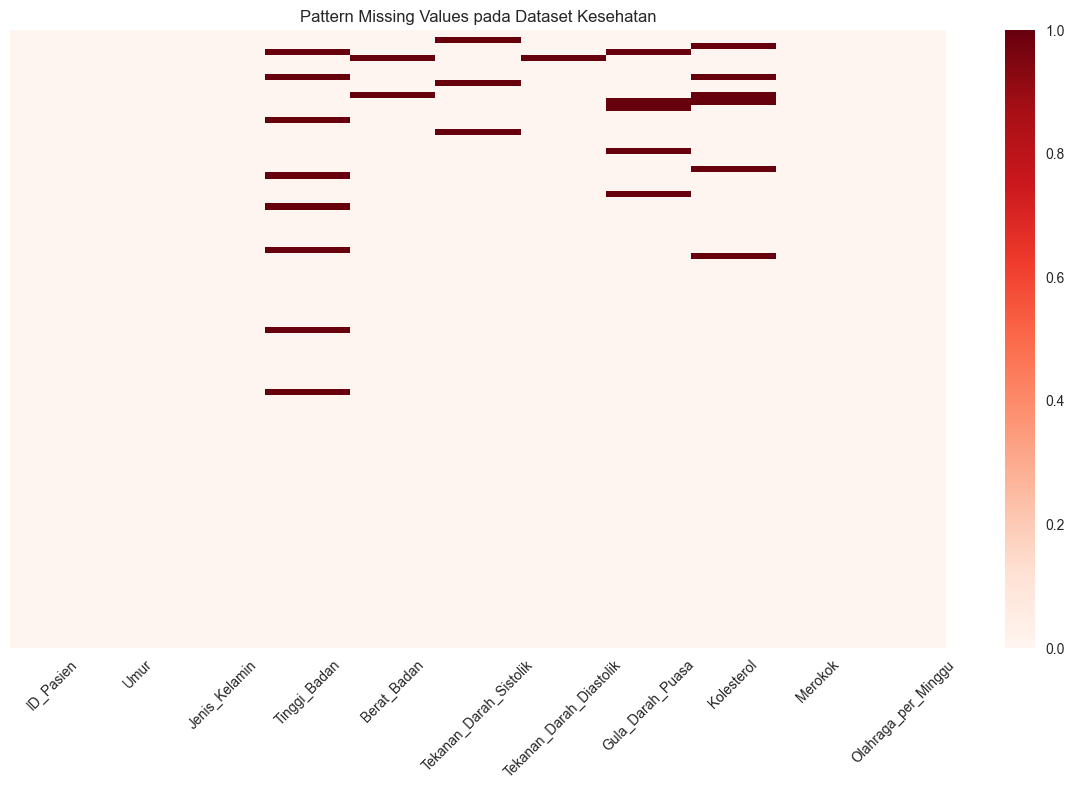

In [29]:
# Visualisasi missing value patterns
plt.figure(figsize=(12, 8))
sns.heatmap(df_kesehatan.isnull(), yticklabels=False, cbar=True, cmap='Reds')
plt.title('Pattern Missing Values pada Dataset Kesehatan')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [51]:
# imputed = df_kesehatan.fillna(df_kesehatan.mean(), inplace=True)
# corr = imputed.corr()
# plt.figure(figsize=(10, 8))
# sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, 
#             square=True, linewidths=0.5)
# plt.title('Korelasi antar Missing Values')
# plt.tight_layout()
# plt.show()

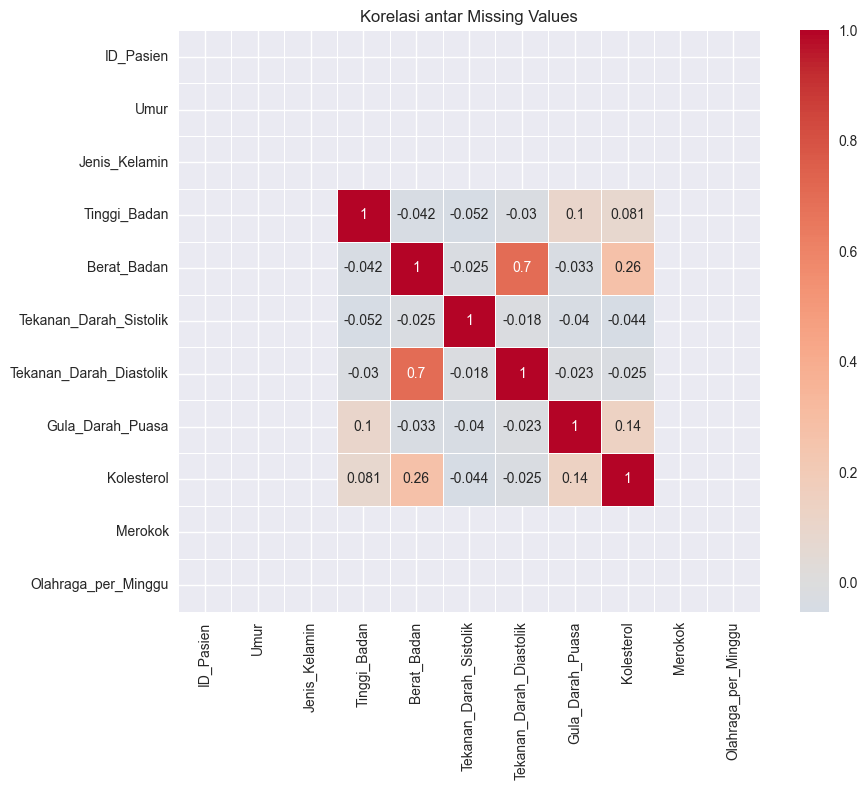

In [30]:
# Analisis korelasi missing values
missing_corr = df_kesehatan.isnull().corr()

plt.figure(figsize=(10, 8))
sns.heatmap(missing_corr, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Korelasi antar Missing Values')
plt.tight_layout()
plt.show()

In [31]:
# Uji Little's MCAR test (simplified version)
def check_missing_pattern(df):
    """
    Simple function to check missing value patterns
    """
    print("=== Analisis Missing Value Patterns ===")
    
    # Check MCAR: Umur vs Tinggi_Badan (harusnya tidak ada korelasi)
    umur_missing_tinggi = df[df['Tinggi_Badan'].isna()]['Umur'].mean()
    umur_notmissing_tinggi = df[df['Tinggi_Badan'].notna()]['Umur'].mean()
    
    print(f"MCAR Test (Tinggi Badan):")
    print(f"  Rata-rata umur (Tinggi Badan missing): {umur_missing_tinggi:.2f}")
    print(f"  Rata-rata umur (Tinggi Badan tidak missing): {umur_notmissing_tinggi:.2f}")
    print(f"  Selisih: {abs(umur_missing_tinggi - umur_notmissing_tinggi):.2f}")
    print(f"  -> {'Kemungkinan MCAR' if abs(umur_missing_tinggi - umur_notmissing_tinggi) < 3 else 'Tidak MCAR'}\n")
    
    # Check MAR: Umur vs Berat_Badan (harusnya ada korelasi)
    umur_missing_berat = df[df['Berat_Badan'].isna()]['Umur'].mean()
    umur_notmissing_berat = df[df['Berat_Badan'].notna()]['Umur'].mean()
    
    print(f"MAR Test (Berat Badan):")
    print(f"  Rata-rata umur (Berat Badan missing): {umur_missing_berat:.2f}")
    print(f"  Rata-rata umur (Berat Badan tidak missing): {umur_notmissing_berat:.2f}")
    print(f"  Selisih: {abs(umur_missing_berat - umur_notmissing_berat):.2f}")
    print(f"  -> {'Kemungkinan MAR' if abs(umur_missing_berat - umur_notmissing_berat) > 3 else 'Tidak ada indikasi MAR'}\n")
    
    # Overall missing pattern
    print("Missing Pattern Summary:")
    total_missing = df.isnull().sum().sum()
    total_cells = df.shape[0] * df.shape[1]
    missing_percentage = (total_missing / total_cells) * 100
    
    print(f"Total missing values: {total_missing}")
    print(f"Total cells: {total_cells}")
    print(f"Missing percentage: {missing_percentage:.2f}%")

check_missing_pattern(df_kesehatan)

=== Analisis Missing Value Patterns ===
MCAR Test (Tinggi Badan):
  Rata-rata umur (Tinggi Badan missing): 36.75
  Rata-rata umur (Tinggi Badan tidak missing): 37.57
  Selisih: 0.82
  -> Kemungkinan MCAR

MAR Test (Berat Badan):
  Rata-rata umur (Berat Badan missing): 49.50
  Rata-rata umur (Berat Badan tidak missing): 37.26
  Selisih: 12.24
  -> Kemungkinan MAR

Missing Pattern Summary:
Total missing values: 25
Total cells: 1100
Missing percentage: 2.27%


### 5.3 Teknik Imputasi Lanjutan

#### 5.3.1 K-Nearest Neighbors (KNN) Imputation

In [ ]:
# KNN Imputation dengan k=5
# Siapkan data untuk KNN imputation
df_sklearn = df_kesehatan.copy()

# Identifikasi kolom numerik untuk imputasi
numeric_cols = df_sklearn.select_dtypes(include=[np.number]).columns.tolist()

# Imputasi Mean untuk perbandingan
imputer_mean = SimpleImputer(strategy='mean')
df_sklearn_mean = df_sklearn.copy()
df_sklearn_mean[numeric_cols] = imputer_mean.fit_transform(df_sklearn[numeric_cols])

# Imputasi Median untuk perbandingan
imputer_median = SimpleImputer(strategy='median')
df_sklearn_median = df_sklearn.copy()
df_sklearn_median[numeric_cols] = imputer_median.fit_transform(df_sklearn[numeric_cols])

# Buat imputer KNN
imputer_knn = KNNImputer(n_neighbors=5)
df_knn = df_sklearn.copy()
df_knn[numeric_cols] = imputer_knn.fit_transform(df_sklearn[numeric_cols])

print("KNN Imputation Results (n_neighbors=5):")
print(f"Jumlah missing values setelah KNN imputation: {df_knn[numeric_cols].isnull().sum().sum()}")

# Perbandingan statistik
print("\nPerbandingan Statistik Kolom Contoh (Tinggi Badan):")
print("Original data:")
print(f"  Mean: {df_sklearn['Tinggi_Badan'].mean():.2f}")
print(f"  Std: {df_sklearn['Tinggi_Badan'].std():.2f}")
print(f"  Min: {df_sklearn['Tinggi_Badan'].min():.2f}")
print(f"  Max: {df_sklearn['Tinggi_Badan'].max():.2f}")

print("\nAfter KNN Imputation:")
print(f"  Mean: {df_knn['Tinggi_Badan'].mean():.2f}")
print(f"  Std: {df_knn['Tinggi_Badan'].std():.2f}")
print(f"  Min: {df_knn['Tinggi_Badan'].min():.2f}")
print(f"  Max: {df_knn['Tinggi_Badan'].max():.2f}")

KNN Imputation Results (n_neighbors=5):
Jumlah missing values setelah KNN imputation: 0

Perbandingan Statistik Kolom Contoh (Tinggi Badan):
Original data:
  Mean: 168.30
  Std: 3.93
  Min: 160.30
  Max: 176.30

After KNN Imputation:
  Mean: 168.20
  Std: 3.84
  Min: 160.30
  Max: 176.30


#### 5.3.2 Iterative Imputation (MICE)

In [ ]:
from catboost import CatboostRegressor, Pool

imputer_iter = IterativeImputer(random_state=42, max_iter=10)
imputer_iter = IterativeImputer(estimator=CatboostRegressor(verbose=0), initial_strategy='mean', random_state=42, max_iter=10)
imputer_iter = IterativeImputer(random_state=42) # default, make baynesian dan mean

In [33]:
# Iterative Imputation (MICE - Multiple Imputation by Chained Equations)
imputer_iter = IterativeImputer(random_state=42, max_iter=10)
df_iterative = df_sklearn.copy()
df_iterative[numeric_cols] = imputer_iter.fit_transform(df_sklearn[numeric_cols])

print("Iterative Imputation Results:")
print(f"Jumlah missing values setelah Iterative imputation: {df_iterative[numeric_cols].isnull().sum().sum()}")

Iterative Imputation Results:
Jumlah missing values setelah Iterative imputation: 0


In [ ]:
# Iterative Imputation (MICE - Multiple Imputation by Chained Equations)
from catboost import CatboostRegressor

imputer_iter = IterativeImputer(estimator=CatboostRegressor(verbose=0) ,random_state=42, max_iter=10)
df_iterative = df_sklearn.copy()
df_iterative[numeric_cols] = imputer_iter.fit_transform(df_sklearn[numeric_cols])

print("Iterative Imputation Results:")
print(f"Jumlah missing values setelah Iterative imputation: {df_iterative[numeric_cols].isnull().sum().sum()}")

In [34]:
# Perbandingan semua metode untuk beberapa kolom
comparison_cols = ['Tinggi_Badan', 'Berat_Badan', 'Gula_Darah_Puasa']

print("\nPerbandingan Metode Imputasi:")
for col in comparison_cols:
    print(f"\n{col}:")
    print(f"  Original mean: {df_sklearn[col].mean():.2f} (missing: {df_sklearn[col].isnull().sum()})")
    print(f"  Mean imputation: {df_sklearn_mean[col].mean():.2f}")
    print(f"  Median imputation: {df_sklearn_median[col].mean():.2f}")
    print(f"  KNN imputation: {df_knn[col].mean():.2f}")
    print(f"  Iterative imputation: {df_iterative[col].mean():.2f}")


Perbandingan Metode Imputasi:

Tinggi_Badan:
  Original mean: 168.30 (missing: 8)
  Mean imputation: 168.30
  Median imputation: 168.27
  KNN imputation: 168.20
  Iterative imputation: 168.25

Berat_Badan:
  Original mean: 67.51 (missing: 2)
  Mean imputation: 67.51
  Median imputation: 67.41
  KNN imputation: 67.78
  Iterative imputation: 67.68

Gula_Darah_Puasa:
  Original mean: 111.01 (missing: 5)
  Mean imputation: 111.01
  Median imputation: 110.91
  KNN imputation: 110.91
  Iterative imputation: 111.03


### 5.4 Visualisasi Perbandingan Imputasi

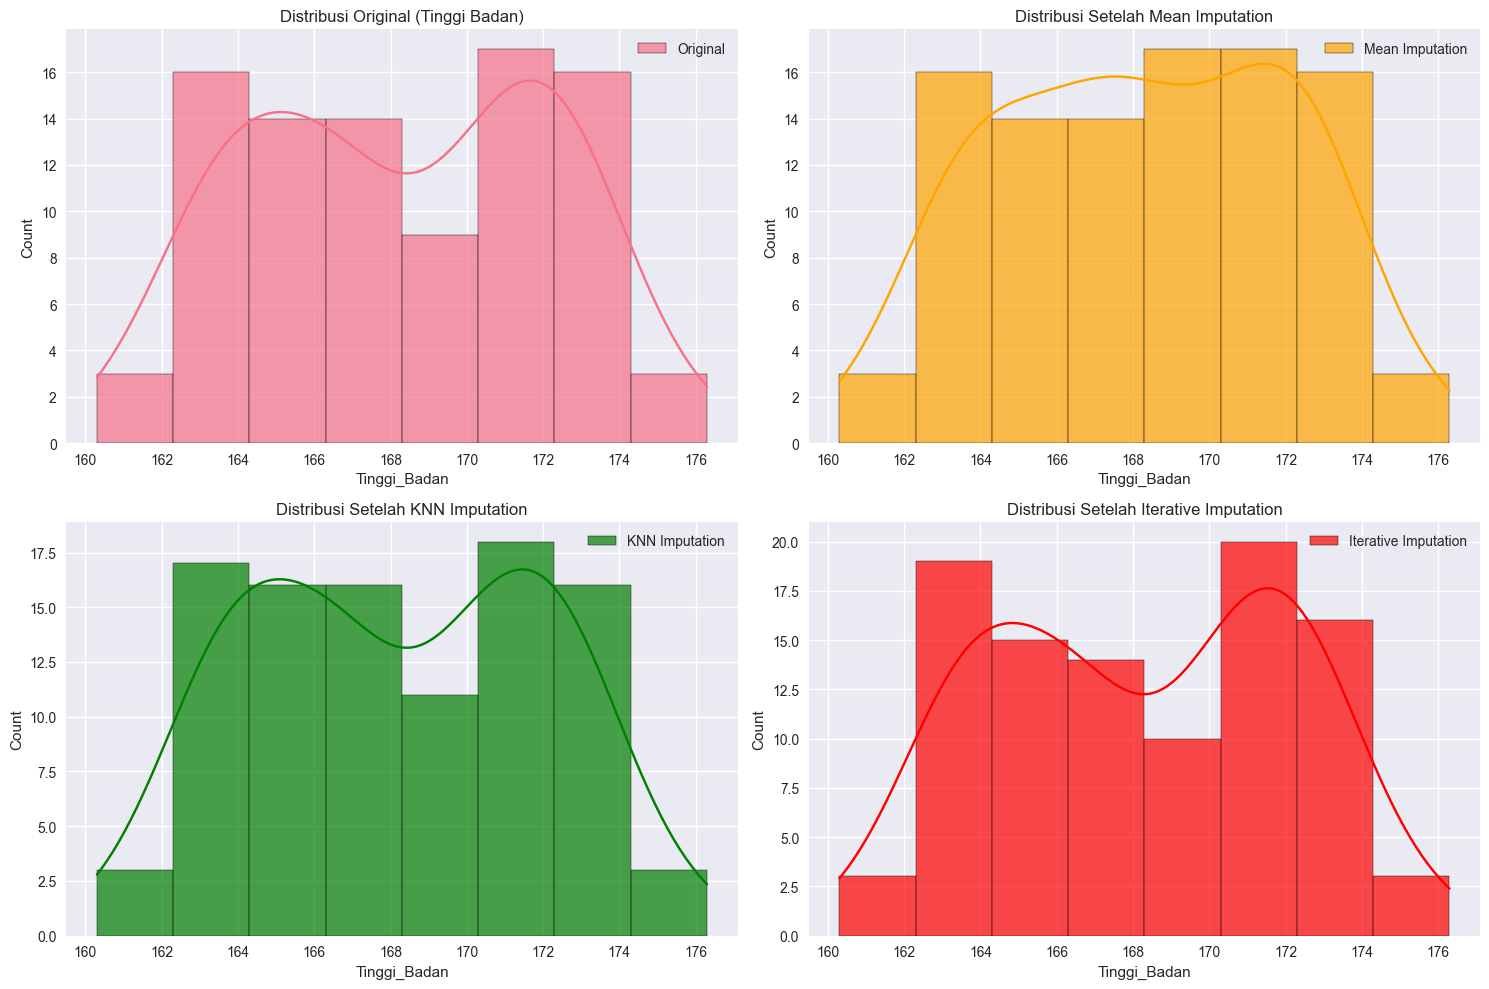

In [35]:
# Visualisasi distribusi sebelum dan sesudah imputasi
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Original data dengan missing values
sns.histplot(df_sklearn['Tinggi_Badan'].dropna(), kde=True, ax=axes[0,0], alpha=0.7, label='Original')
axes[0,0].set_title('Distribusi Original (Tinggi Badan)')
axes[0,0].legend()

# Mean imputation
sns.histplot(df_sklearn_mean['Tinggi_Badan'], kde=True, ax=axes[0,1], alpha=0.7, color='orange', label='Mean Imputation')
axes[0,1].set_title('Distribusi Setelah Mean Imputation')
axes[0,1].legend()

# KNN imputation
sns.histplot(df_knn['Tinggi_Badan'], kde=True, ax=axes[1,0], alpha=0.7, color='green', label='KNN Imputation')
axes[1,0].set_title('Distribusi Setelah KNN Imputation')
axes[1,0].legend()

# Iterative imputation
sns.histplot(df_iterative['Tinggi_Badan'], kde=True, ax=axes[1,1], alpha=0.7, color='red', label='Iterative Imputation')
axes[1,1].set_title('Distribusi Setelah Iterative Imputation')
axes[1,1].legend()

plt.tight_layout()
plt.show()

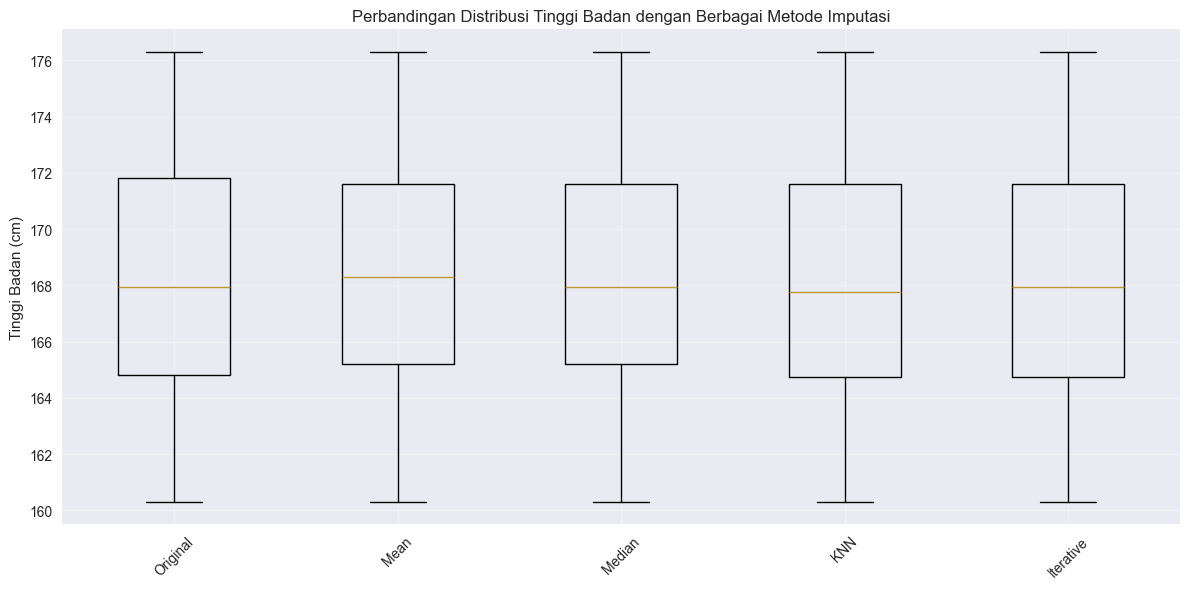

In [36]:
# Boxplot comparison
plt.figure(figsize=(12, 6))

data_to_plot = [
    df_sklearn['Tinggi_Badan'].dropna(),
    df_sklearn_mean['Tinggi_Badan'],
    df_sklearn_median['Tinggi_Badan'],
    df_knn['Tinggi_Badan'],
    df_iterative['Tinggi_Badan']
]

labels = ['Original', 'Mean', 'Median', 'KNN', 'Iterative']

plt.boxplot(data_to_plot, labels=labels)
plt.title('Perbandingan Distribusi Tinggi Badan dengan Berbagai Metode Imputasi')
plt.ylabel('Tinggi Badan (cm)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Kesimpulan dan Best Practices

### 7.1 Ringkasan Metode Imputasi

| Metode | Kelebihan | Kekurangan | Kapan Digunakan |
|--------|-----------|------------|-----------------|
| **Mean** | Sederhana, cepat | Distorsi distribusi, sensitif outlier | MCAR, data terdistribusi normal |
| **Median** | Robust terhadap outlier | Tidak mempertahankan variansi | Data dengan outlier, skewed distribution |
| **Modus** | Cocok untuk kategorikal | Bisa mengganggu distribusi | Data kategorikal, data ordinal |
| **KNN** | Pertimbangkan korelasi | Komputasi intensif, sensitif k | Data dengan korelasi tinggi |
| **Iterative** | Akurat untuk data kompleks | Mahal komputasi, kompleks | Data dengan pattern MAR/MNAR |
| **Deletion** | Sederhana | Hilang informasi | Missing values sedikit (<5%) |

### 7.2 Best Practices untuk Data Wrangling:

1. **Pahami Data Anda**: Selalu lakukan EDA (Exploratory Data Analysis) terlebih dahulu
2. **Identifikasi Missing Pattern**: Bedakan antara MCAR, MAR, dan MNAR
3. **Pilih Metode yang Tepat**: Sesuaikan dengan karakteristik data dan tujuan analisis
4. **Validasi Hasil**: Periksa distribusi dan statistik setelah imputasi
5. **Dokumentasi**: Catat semua langkah preprocessing yang dilakukan
6. **Konsultasi Domain Expert**: Validasi hasil imputasi dengan pengetahuan domain

### 7.3 Error Handling dan Troubleshooting:

1. **Jika terlalu banyak missing values (>50%):** Pertimbangkan untuk menghapus kolom
2. **Jika distribusi berubah drastis setelah imputasi:** Coba metode lain
3. **Jika data time series:** Gunakan metode imputasi temporal (forward fill, backward fill)
4. **Jika data kategorikal:** Gunakan modus atau buat kategori 'Unknown'
5. **Jika ada outlier:** Gunakan median atau robust imputation methods